In [96]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [97]:
df = pd.read_csv('../data/adult/adult.data.csv', na_values=['?'], skipinitialspace=True)
df.columns=['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

In [98]:
df.sample(5)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
26542,41,Private,193882,Bachelors,13,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,40,United-States,<=50K
4173,17,NaN,114798,11th,7,Never-married,NaN,Own-child,White,Female,0,0,18,United-States,<=50K
24503,60,State-gov,352156,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,>50K
6925,45,Private,187730,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,<=50K
27744,36,Self-emp-not-inc,239415,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,35,United-States,<=50K


In [99]:
df['income'] = np.where(df['income'] == '>50K', 1, 0)
cat_cols =['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex',  'native_country']

df_encoded = pd.get_dummies(df, columns=cat_cols)

x = df_encoded.drop('income', axis=1)
y = df_encoded['income']

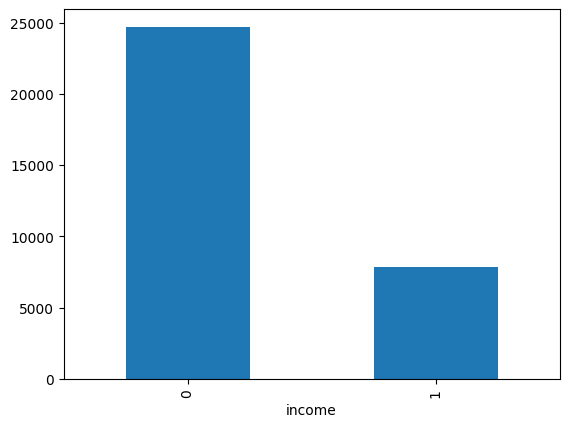

In [100]:
y_value_count = y.value_counts()
y_value_count.plot(kind='bar')
plt.show()

In [101]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 

In [102]:
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)
y_pred = rfc.predict(x_test)
cm = confusion_matrix(y_test, y_pred)

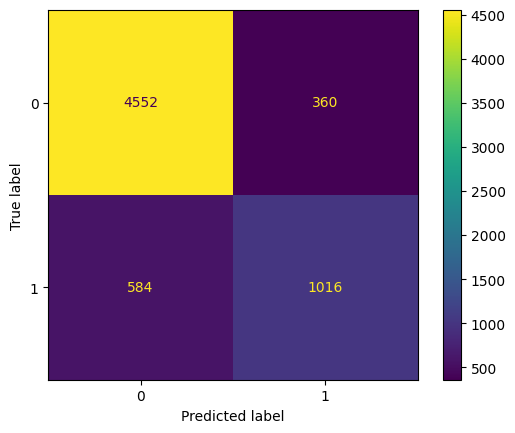

In [103]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()

In [104]:
accuracy_score(y_test, y_pred)

0.855036855036855

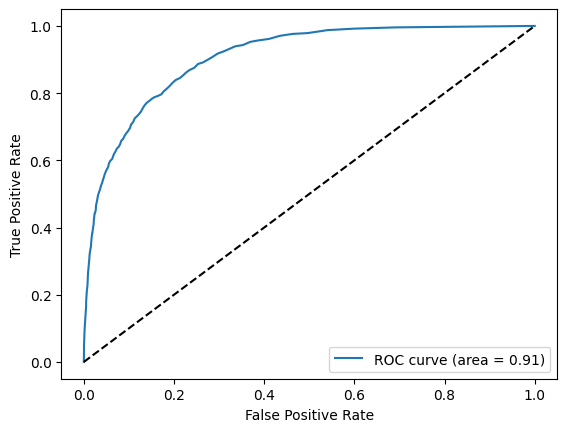

In [105]:
y_proba = rfc.predict_proba(x_test)[:,1]
fpr, tpr, threshold = roc_curve(y_test, y_proba, pos_label=1)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()